# Pytorch Custom Dataset

## 0.Import Pytorch and Device Agnostik

In [2]:
import torch
from torch import nn

torch.__version__

'2.10.0+cu128'

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1.Import The Datasets

In [1]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


In [5]:
import os

def walk_through_dir(dir_path):
    """
    Walks through dir_path returning its contents.
    args:
        dir_path (str or pathlib.Path): target directory
    returns:
        number of subdirectories in dir_path,
        number of images (files) in each subdirectory, and the names of the subdirectories in dir_path
        name of each subdirencory
    """
    
    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} image in '{dirpath}'")
    

In [6]:
walk_through_dir(image_path)

There are 2 directories and 0 image in 'data/pizza_steak_sushi'
There are 3 directories and 0 image in 'data/pizza_steak_sushi/train'
There are 0 directories and 72 image in 'data/pizza_steak_sushi/train/sushi'
There are 0 directories and 78 image in 'data/pizza_steak_sushi/train/pizza'
There are 0 directories and 75 image in 'data/pizza_steak_sushi/train/steak'
There are 3 directories and 0 image in 'data/pizza_steak_sushi/test'
There are 0 directories and 31 image in 'data/pizza_steak_sushi/test/sushi'
There are 0 directories and 25 image in 'data/pizza_steak_sushi/test/pizza'
There are 0 directories and 19 image in 'data/pizza_steak_sushi/test/steak'


In [7]:
# setup the training and testing paths
train_dir = image_path / "train"
test_dir = image_path/"test"

train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

Random image path: data/pizza_steak_sushi/test/pizza/1687143.jpg
Image class: pizza
Image height: 512
Image width: 512


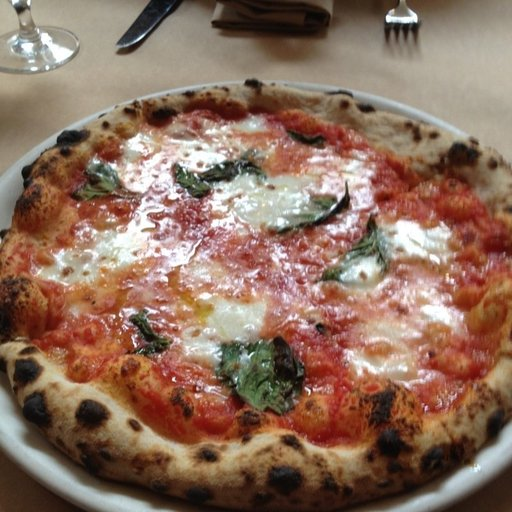

In [17]:
import random
from PIL import Image

# set seed 
random.seed(30)

# get all image paths 
image_path_list = list(image_path.glob("*/*/*.jpg"))

# get random image path
random_image_path = random.choice(image_path_list)

# get image class from path name
image_class = random_image_path.parent.stem

# open the image
img = Image.open(random_image_path)

# pring metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

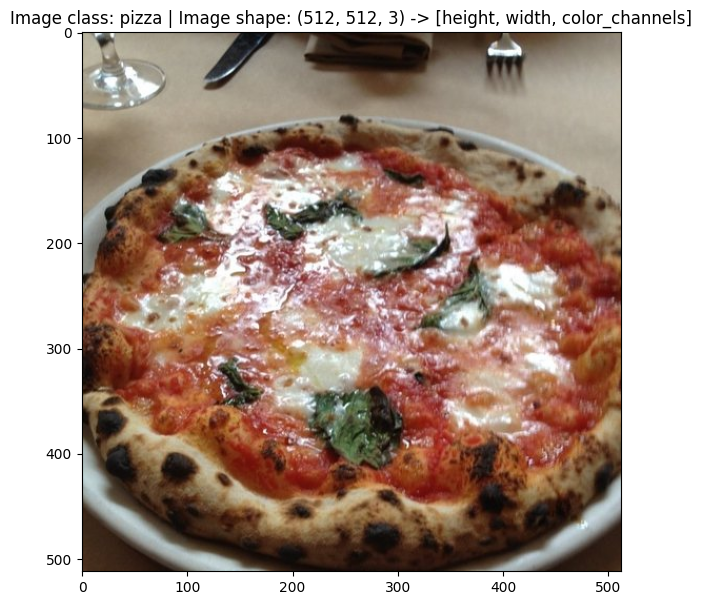

In [18]:
import numpy as np 
import matplotlib.pyplot as plt 

# turn the image into an array
img_as_array = np.asarray(img)

# plot the image with matplotlib
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.show()

## 3.Tranform The Dataset

In [19]:
import torch 
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [21]:
data_transform = transforms.Compose([
    # resize the image to 64 x 64
    transforms.Resize(size=(64,64)),
    
    # Flip the image randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    
    # turn the image into a torch.Tensor
    transforms.ToTensor() # also change pizel value from 0 - 255 to 0 - 1
])

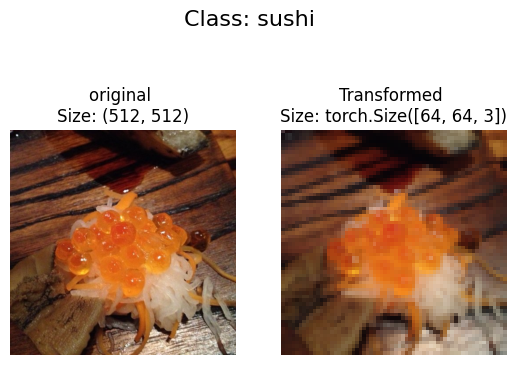

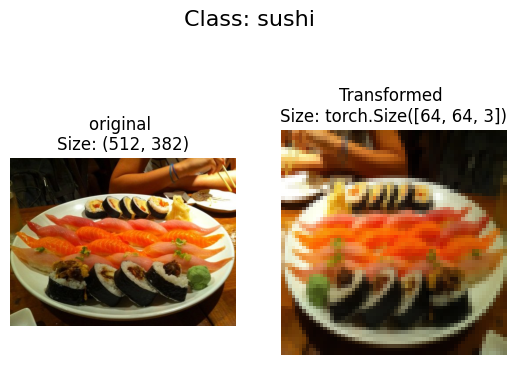

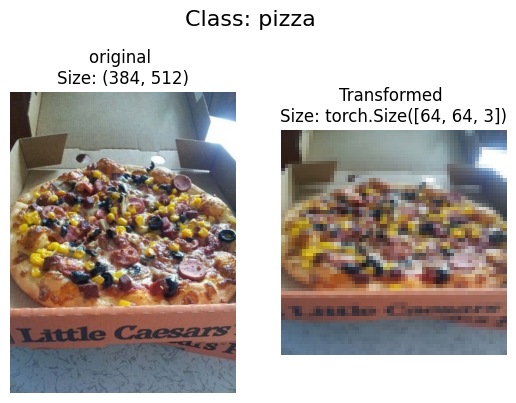

In [23]:
def plot_transformed_images(image_paths,transform,n=3,seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths. 
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
    """ 
    
    random.seed(seed)
    random_image_paths = random.sample(image_paths,k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig,ax = plt.subplots(1,2)
            ax[0].imshow(f)
            ax[0].set_title(f"original \nSize: {f.size}")
            ax[0].axis("off")
            
            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib 
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            
            transformed_image = transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")
            
            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list, 
                        transform=data_transform, 
                        n=3)

## 4.Option 1: Loading Image Data Using Image Folder

In [24]:
from torchvision import datasets

train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [25]:
# Get class name as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [26]:
# can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [27]:
# Check the lengths
len(train_data) , len(test_data)

(225, 75)

In [29]:
img,label = train_data[0][0] ,train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"image datatype: {img.dtype}")
print(f"image label: {label}")
print(f"label datatype: {type(label)}")

Image tensor:
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

Original shape: torch.Size([3, 64, 64])
Image permute shape: torch.Size([64, 64, 3])


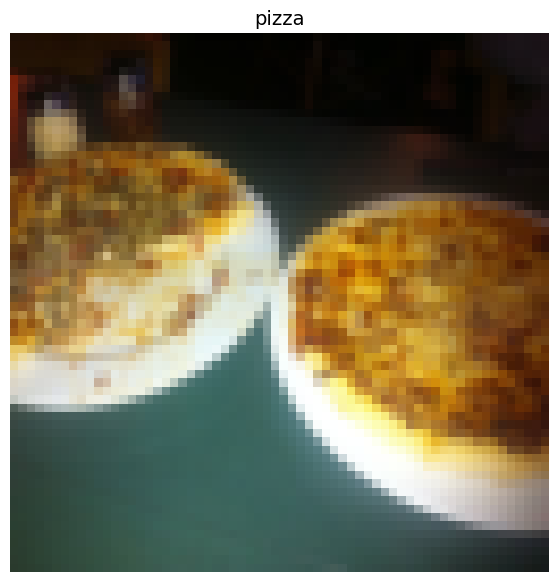

In [31]:
# rearange the order of dimensions -> pytorch using (C,H,W) matplotlib C is last
img_permute =  img.permute(1,2,0)

# print out the different shape
print(f"Original shape: {img.shape}")
print(f"Image permute shape: {img_permute.shape}")

# plot the Image
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_names[label], fontsize=14);

### 4.1.Data Loader

In [32]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=1,
                              num_workers=1,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=1,
                             num_workers=1,
                             shuffle=False)

train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7676d8866530>,
 <torch.utils.data.dataloader.DataLoader at 0x7676d8866080>)

In [34]:
img,label = next(iter(train_dataloader))

print(f"Image shape: {img.shape}")
print(f"label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64])
label shape: torch.Size([1])


## 5. Option 2 Custom Datasets

In [35]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [36]:
# instance of torchvision.datasets.ImageFolder()
train_data.classes , train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [39]:
# setup path for target directory
target_directory = train_dir
print(f"Target directory: {target_directory}")

# Get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(image_path/"train"))])
print(f"Class names found: {class_names_found}")

Target directory: data/pizza_steak_sushi/train
Class names found: ['pizza', 'steak', 'sushi']


In [54]:
# Make function to find classes in target directory
def find_classes(directory:str) -> Tuple[List[str],Dict[str,int]]:
    """Finds the class folder names in a target directory.
    
    Assumes target directory is in standard image classification format.

    Args:
        directory (str): target directory to load classnames from.

    Returns:
        Tuple[List[str], Dict[str, int]]: (list_of_class_names, dict(class_name: idx...))
    
    Example:
        find_classes("food_images/train")
        >>> (["class_1", "class_2"], {"class_1": 0, ...})
    """
    
    # Get the class names by scanning the target directory
    classes = sorted([entry.name for entry in list(os.scandir(directory)) if entry.is_dir()])
    
    # raise an error is class not found
    if not classes:
        raise FileNotFoundError(f"couldn't found any classes in {directory}")
    
    # create dictionary of index label 
    class_to_idx = {cls_name:i for i,cls_name in enumerate(classes)}
    
    return classes,class_to_idx
    
    

In [55]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2. Create Custom Dataset to replecate ImageFolder

In [56]:
# write a custom dataset class inherit from torch.utils.data.Dataset
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
    
    # 2. initalize with a targ_dir and transform (optional parameter)
    def __init__(self,targ_dir:str,transform=None) -> None:
        # 3. create class atributes
        # Get all image paths
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        
        # setup transform
        self.transform = transform
        
        # create classes and class_to_idx attributs
        self.classes, self.class_to_idx = find_classes(targ_dir)
        
    # 4. Make Function to load images
    def load_image(self,index:int) -> Image.Image:
        "open an image via path and returns it"
        image_path = self.paths[index]
        return Image.open(image_path)
    
    # 5. Overwrite the __len__() method (optional but recommended for subclasses of torch.utils.data.Dataset)
    def __len__(self) -> int:
        "return the toal number of samples"
        return len(self.paths)
    
    # 6. Overwrite the __getitem__() method (required for subclasses of torch.utils.data.Dataset)
    def __getitem__(self,index:int) -> Tuple[torch.Tensor,int]:
        "Returns one sample of data, data and label (X, y)."
        img = self.load_image(index)
        class_names = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_names]
        
        # Transform if necessary
        if self.transform:
            return self.transform(img),class_idx
        else:
            return img,class_idx
        

In [57]:
# Augment train data
train_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

#  Don't augment test data, only reshape
test_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [58]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transform=train_transforms)

test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transform=test_transforms)

train_data_custom,test_data_custom

(<__main__.ImageFolderCustom at 0x7676d84bff40>,
 <__main__.ImageFolderCustom at 0x7676d84bd240>)

In [59]:
len(train_data_custom), len(test_data_custom)

(225, 75)

In [60]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [61]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [62]:
# Check for equality amongst our custom Dataset and ImageFolder Dataset
print((len(train_data_custom) == len(train_data)) & (len(test_data_custom) == len(test_data)))
print(train_data_custom.classes == train_data.classes)
print(train_data_custom.class_to_idx == train_data.class_to_idx)

True
True
True


In [65]:
def display_random_images(
    dataset: torch.utils.data.dataset.Dataset,
    classes:List[str] = None,
    n:int=10,
    display_shape:bool = True,
    seed: int = None
):
    # if n more than ten, then cap it
    if n > 10:
        n = 10
    
    # set the random seed
    random.seed(seed)
    
    # random sample index
    random_sample_indexes = random.sample(range(len(dataset)),k=n)
    
    # setup plot
    plt.figure(figsize=(16,8))
    
    # loop through samples and display random samples
    for i,targ_sampel in enumerate(random_sample_indexes):
        targ_image , targ_label = dataset[targ_sampel][0], dataset[targ_sampel][1]
        
        # adjust bro
        targ_image_adjust = targ_image.permute(1,2,0)
        
        # plot adjusted sample
        plt.subplot(1,n,i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)
        
        
    

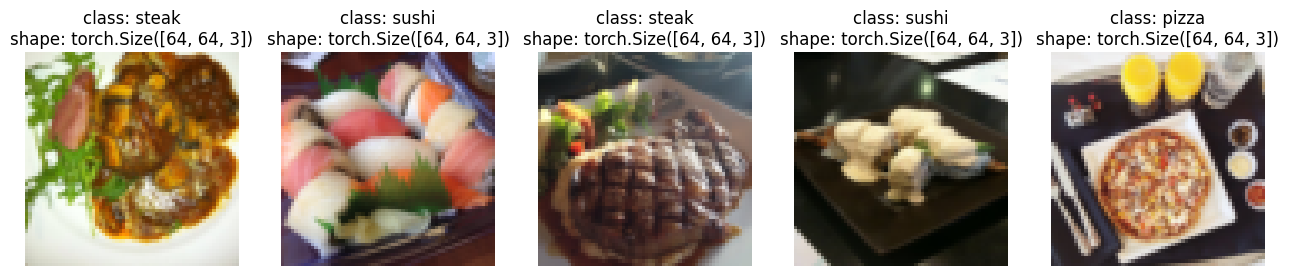

In [69]:
display_random_images(train_data,n=5,classes=class_names,)

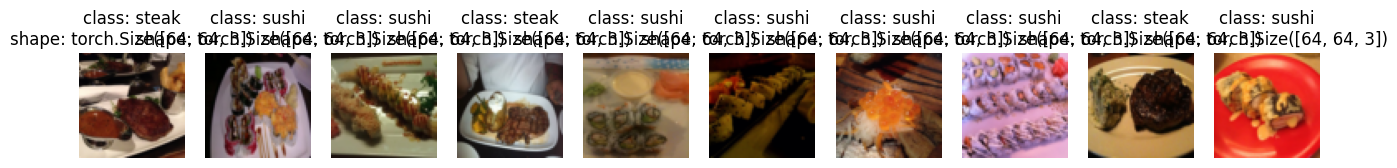

In [70]:
# Display random images from ImageFolderCustom Dataset
display_random_images(train_data_custom, 
                      n=12, 
                      classes=class_names,
                      seed=42) # Try setting the seed for reproducible images

### 5.4.turn Custom Loaded Images into Datalodader

In [71]:
from torch.utils.data import DataLoader
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=1,
                                     num_workers=0,
                                     shuffle=True)

test_dataloader_custom = DataLoader(
    dataset=test_data_custom,
    batch_size=1,
    num_workers=0,
    shuffle=False
)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x767931ec5d20>,
 <torch.utils.data.dataloader.DataLoader at 0x767931ee3a60>)

In [ ]:
# get image and label from custom DataLoader
img_custom,label_custom = next(iter(train_dataloader_custom))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img_custom.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label_custom.shape}")
